# Effects Analysis

This notebook contains the code for the different steps taken in the analysis.

- Rootzone storage 
- Budyko Framework
- River discharge timeseries
- Run-off coefficient 

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ewatercycle.forcing
import ewatercycle.observation.grdc
import ewatercycle.analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from cartopy.io import shapereader
from rich import print
import matplotlib.pyplot as plt
import xarray as xr

# Loading the Data Cagayan de Oro

In [3]:
# Name of shapefile/region
own_region = "Cagayan_de_Oro"

# Shapefile that describes the basin we want to study
path = Path.cwd()
forcing_path = path / "Forcing"
shapeFile = forcing_path / f"{own_region}.shp"

# Location to saved forcing results from previous notebook
forcingLocation = forcing_path / f"{own_region}_1991_2019_Forcing"

#Shape area
shape_area_Cagayan = 1083.18 * 1000000 # m2

# Load ERA5 data
ERA5_forcing_Cagayan = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(forcingLocation)

In [4]:
# Period of interest
experiment_start_time = "2003-01-01T00:00:00Z"
experiment_end_time = "2012-12-31T00:00:00Z"

In [5]:
# Load evap and prec Cagayan de Oro
C_evap = ERA5_forcing_Cagayan.to_xarray()["evspsblpot"]
C_prec = ERA5_forcing_Cagayan.to_xarray()["pr"]
C_evap = C_evap * 86400 # mm/day
C_prec = C_prec * 86400 # mm/day

In [7]:
# Discharge data Cagayan de Oro
C_obs = pd.read_excel('Discharge_19912019_Cagayan.xlsx', index_col=[0])
C_obs = C_obs / 1000 # m3/s
C_obs = C_obs * 86400 / shape_area_Cagayan * 1000 # mm/day
C_obs.loc[C_obs['Q'] > 4000, 'Q'] = np.nan
C_obs_data = C_obs['Q'].to_xarray().rename({'Day': 'time'})

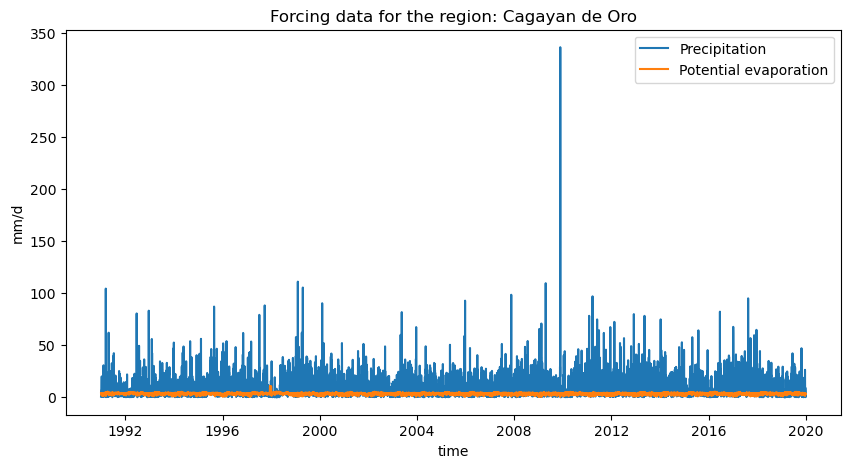

In [12]:
# Data plots
plt.figure(figsize=(10, 5))
C_prec.plot(label='Precipitation')
C_evap.plot(label='Potential evaporation')
plt.title(f'Forcing data for the region: Cagayan de Oro')
plt.ylabel('mm/d')
plt.legend();

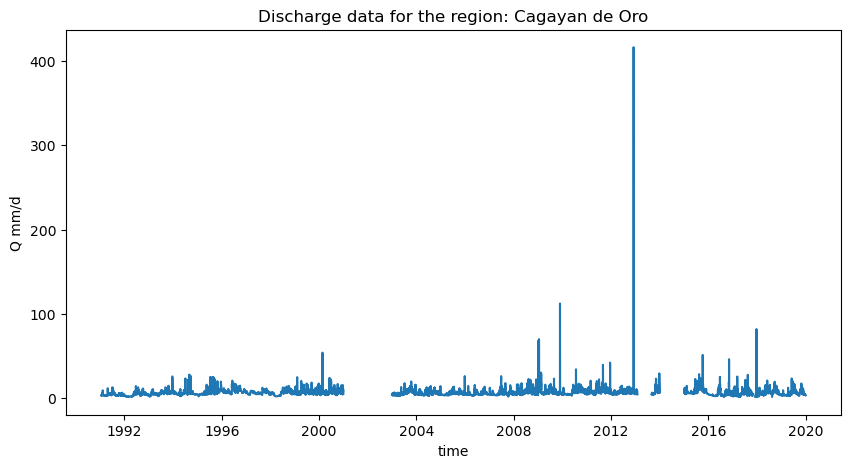

In [16]:
# Data plots
plt.figure(figsize=(10, 5))
C_obs_data.plot()
plt.title(f'Discharge data for the region: Cagayan de Oro')
plt.ylabel('Q mm/d');

# Rootzone storage

In [17]:
C_evap["time"] = C_evap["time"].dt.date
C_prec["time"] = C_prec["time"].dt.date

In [18]:
C_evap.name = "EP mm/d" 
C_prec.name = "P mm/d"
C_obs_data.name = "Q mm/d"

df = xr.merge([C_prec, C_evap, C_obs_data]).to_dataframe()
Cagayan = df[["P mm/d", "EP mm/d", "Q mm/d"]].dropna()
Cagayan.index = pd.to_datetime(Cagayan.index)
Cagayan

,P mm/d,EP mm/d,Q mm/d
time,,,
1991-01-16,2.945107,2.031221,3.533596
1991-01-17,1.071095,2.083669,3.190605
1991-01-18,2.552277,2.799082,3.190605
1991-01-19,13.945623,1.719752,3.190605
1991-01-20,15.782014,2.488085,3.190605
...,...,...,...
2019-12-27,3.364178,3.098087,4.044890
2019-12-28,1.434635,3.548304,3.810381
2019-12-29,0.544718,3.392103,3.598205


In [37]:
Cagayan_pre_deforestation = Cagayan.loc["1991-01-01":"1994-12-31"]
Cagayan_post_deforestation = Cagayan.loc["1996-01-01":"1999-12-31"]

In [30]:
ET_LT_pre = Cagayan_pre_deforestation['P mm/d'].mean() - Cagayan_pre_deforestation['Q mm/d'].mean()
df2_pre = pd.DataFrame(index=Cagayan_pre_deforestation.index)

In [31]:
ET_pre = Cagayan_pre_deforestation['EP mm/d'] * (ET_LT_pre / Cagayan_pre_deforestation['EP mm/d'].mean())
df2_pre['ET_pre'] = ET_pre

In [32]:
SD_pre = np.zeros(len(Cagayan_pre_deforestation['P mm/d']))

for i in range(len(SD_pre)):
    SD_pre[i] = np.minimum(0, SD_pre[i-1] + Cagayan_pre_deforestation['P mm/d'][i] - ET_pre[i])

df2_pre['SD_pre'] = SD_pre

In [33]:
ET_LT_post = Cagayan_post_deforestation['P mm/d'].mean() - Cagayan_post_deforestation['Q mm/d'].mean()
df2_post = pd.DataFrame(index=Cagayan_post_deforestation.index)

In [34]:
ET_post = Cagayan_post_deforestation['EP mm/d'] * (ET_LT_post / Cagayan_post_deforestation['EP mm/d'].mean())
df2_post['ET_post'] = ET_post

In [35]:
SD_post = np.zeros(len(Cagayan_post_deforestation['P mm/d']))

for i in range(len(SD_post)):
    SD_post[i] = np.minimum(0, SD_post[i-1] + Cagayan_post_deforestation['P mm/d'][i] - ET_post[i])

df2_post['SD_post'] = SD_post

The maximum storage deficit post deforestation (1996-1999) is -224.09 mm, which is interesting as this would be 
expected to be smaller than pre deforestation.

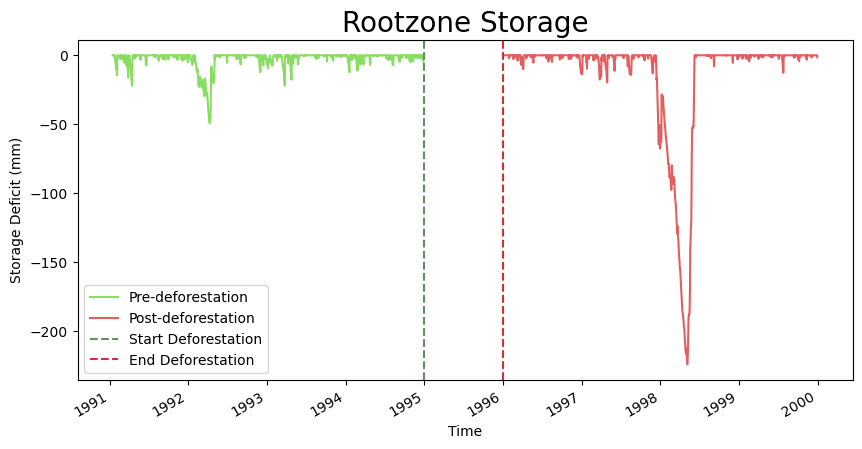

In [36]:
# Plot
plt.figure(figsize=(10, 5))

df2_pre['SD_pre'].plot(label='Pre-deforestation', color='#89DD63')
df2_post['SD_post'].plot(label='Post-deforestation', color='#E35E5E')
font = {'family': 'sans-serif', 'color': 'black', 'weight': 'normal', 'size': 10}
plt.title("Rootzone Storage", fontdict=font, fontsize=20)
plt.ylabel("Storage Deficit (mm)", fontdict=font)
plt.xlabel('Time', fontdict=font)
plt.axvline(x='1995-01-01', color='#60905B', linestyle='--', label='Start Deforestation')
plt.axvline(x='1996-01-01', color='#D52E31', linestyle='--', label='End Deforestation')
plt.legend()
print(f'The maximum storage deficit post deforestation (1996-1999) is {df2_post['SD_post'].min():.2f} mm, which is interesting as this would be expected to be smaller than pre deforestation.')

# Budyko Framework

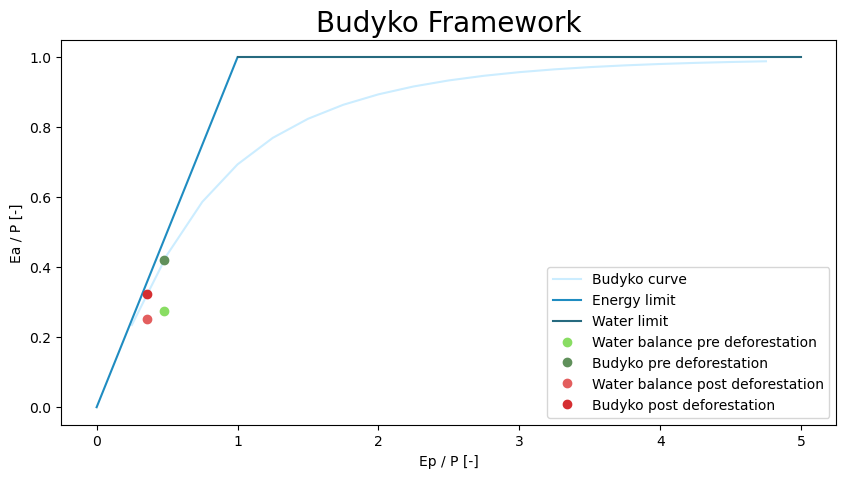

In [40]:
# Plot
ep_p = np.arange(0.25, 5, 0.25)
budyko = (ep_p * np.tanh(1 / ep_p) * (1 - np.exp(-ep_p))) ** 0.5

EP_P_1 = Cagayan_pre_deforestation['EP mm/d'].mean() / Cagayan_pre_deforestation['P mm/d'].mean()
ET_P_1 = df2_pre['ET_pre'].mean() / Cagayan_pre_deforestation['P mm/d'].mean()
budyko1 = (EP_P_1 * np.tanh(1 / EP_P_1) * (1 - np.exp(-EP_P_1))) ** 0.5

EP_P_2 = Cagayan_post_deforestation['EP mm/d'].mean() / Cagayan_post_deforestation['P mm/d'].mean()
ET_P_2 = df2_post['ET_post'].mean() / Cagayan_post_deforestation['P mm/d'].mean()
budyko2 = (EP_P_2 * np.tanh(1 / EP_P_2) * (1 - np.exp(-EP_P_2))) ** 0.5

plt.figure(figsize=(10, 5))

plt.plot(ep_p, budyko, color='#CCEDFF', label='Budyko curve')
plt.plot([0, 1], [0, 1], color='#1F8CC1', label='Energy limit')
plt.plot([1, 5], [1, 1], color='#266A7F', label='Water limit')

plt.plot(EP_P_1, ET_P_1, 'o', color='#89DD63', label='Water balance pre deforestation')
plt.plot(EP_P_1, budyko1, 'o', color='#60905B', label='Budyko pre deforestation')

plt.plot(EP_P_2, ET_P_2, 'o', color='#E35E5E', label='Water balance post deforestation')
plt.plot(EP_P_2, budyko2, 'o', color='#D52E31', label='Budyko post deforestation')
plt.title('Budyko Framework', fontdict=font, fontsize=20)
plt.legend()
plt.xlabel('Ep / P [-]', fontdict=font)
plt.ylabel('Ea / P [-]', fontdict=font)
plt.show();

# River Discharge Timeseries

The mean discharge before deforestation is: 5.32 mm/d.

The mean discharge after deforestation is: 7.36 mm/d.

This is a 27.75% increase.

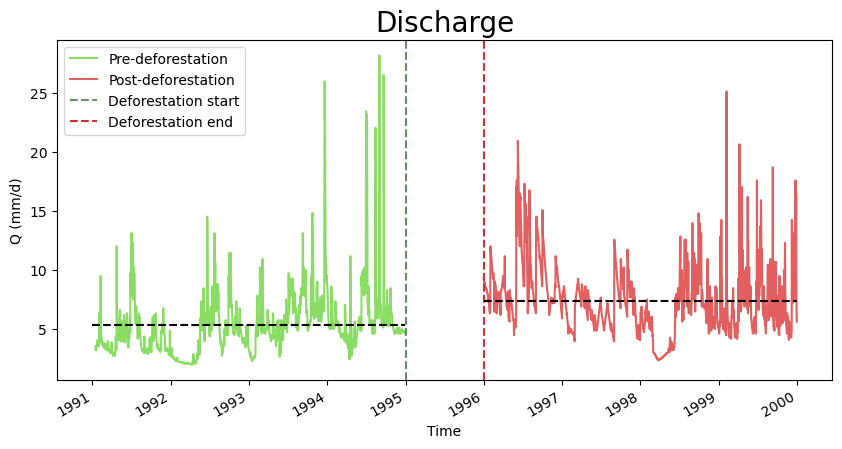

In [41]:
# Plot for Poster
plt.figure(figsize=(10, 5))

Cagayan_pre_deforestation['Q mm/d'].plot(color='#89DD63', label='Pre-deforestation')
Cagayan_post_deforestation['Q mm/d'].plot(color='#E35E5E', label='Post-deforestation')
plt.axvline(x='1995-01-01', color='#60905B', linestyle='--', label='Deforestation start')
plt.axvline(x='1996-01-01', color='#D52E31', linestyle='--', label='Deforestation end')
plt.plot([pd.Timestamp('1991-01-01'), pd.Timestamp('1994-12-31')], [Cagayan_pre_deforestation['Q mm/d'].loc['1991-01-01':'1994-12-31'].mean(), Cagayan_pre_deforestation['Q mm/d'].loc['1991-01-01':'1994-12-31'].mean()], linestyle='--', color='black')
plt.plot([pd.Timestamp('1996-01-01'), pd.Timestamp('1999-12-31')], [Cagayan_post_deforestation['Q mm/d'].loc['1996-01-01':'1999-12-31'].mean(), Cagayan_post_deforestation['Q mm/d'].loc['1996-01-01':'1999-12-31'].mean()], linestyle='--', color='black')

plt.title("Discharge", fontdict=font, fontsize=20)
plt.ylabel("Q (mm/d)", fontdict=font)
plt.xlabel('Time', fontdict=font)
plt.legend()

print(f'The mean discharge before deforestation is: {Cagayan_pre_deforestation['Q mm/d'].loc['1991-01-01':'1994-12-31'].mean():.2f} mm/d.')
print(f'The mean discharge after deforestation is: {Cagayan_post_deforestation['Q mm/d'].loc['1996-01-01':'1999-12-31'].mean():.2f} mm/d.')
print(f'This is a {(Cagayan_post_deforestation['Q mm/d'].loc['1996-01-01':'1999-12-31'].mean() - Cagayan_pre_deforestation['Q mm/d'].loc['1991-01-01':'1994-12-31'].mean())/Cagayan_post_deforestation['Q mm/d'].loc['1996-01-01':'1999-12-31'].mean()*100:.2f}% increase.');

To analyse whether such a change in mean river discharge can be directly attributed to deforestation, other samples of the timeseries were taken to see if such large jumps occur more frequent in the discharge timeseries.

In [44]:
# 1991-1992 vs. 1995-1996
pre = C_obs.loc['1991-01-01':'1992-12-31']
post = C_obs.loc['1995-01-01':'1996-12-31']

print(f'The difference in mean river discharge is {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is 49.71%.

In [45]:
# 2003-2006 vs. 2008-2011
pre = C_obs.loc['2003-01-01':'2006-12-31']
post = C_obs.loc['2008-01-01':'2011-12-31']

print(f'The difference in mean river discharge is {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is 25.85%.

In [46]:
# 1991-1993 vs. 1994-1996
pre = C_obs.loc['1991-01-01':'1993-12-31']
post = C_obs.loc['1994-01-01':'1996-12-31']

print(f'The difference in mean river discharge is {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is 36.23%.

In [47]:
# 1991-1997 vs. 1998-2000
pre = C_obs.loc['1991-01-01':'1997-12-31']
post = C_obs.loc['1998-01-01':'2000-12-31']

print(f'The difference in mean river discharge is  {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is  5.78%.

In [48]:
# 1993-1997 vs. 1998-2000
pre = C_obs.loc['1993-01-01':'1997-12-31']
post = C_obs.loc['1998-01-01':'2000-12-31']

print(f'The difference in mean river discharge is {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is -6.26%.

In [49]:
# 2003-2006 vs. 2007-2010
pre = C_obs.loc['2003-01-01':'2006-12-31']
post = C_obs.loc['2007-01-01':'2010-12-31']

print(f'The difference in mean river discharge is {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is 18.96%.

In [50]:
# 2003-2007 vs. 2008-2011
pre = C_obs.loc['2003-01-01':'2007-12-31']
post = C_obs.loc['2008-01-01':'2011-12-31']

print(f'The difference in mean river discharge is  {(post['Q'].mean() - pre['Q'].mean())/post['Q'].mean()*100:.2f}%.');

The difference in mean river discharge is  26.25%.

# Runoff Coefficient

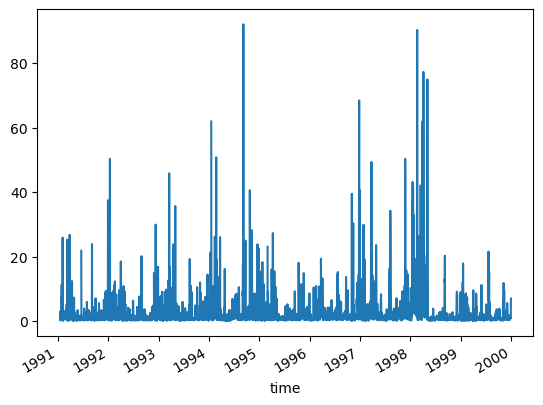

In [51]:
# Daily run-off coefficient
Cagayan['Runoff Coefficient'] = Cagayan['Q mm/d'] / Cagayan['P mm/d']
Deforestation = Cagayan.loc['1991-01-16':'1999-12-31']
Deforestation.loc[Deforestation['Runoff Coefficient'] > 100, 'Runoff Coefficient'] = np.nan
Deforestation['Runoff Coefficient'].plot();

The daily run-off coefficient shows very high values, over 60 sometimes, which should not be possible as the range is 0-1. Thus, the analysis was tried with the monthly sums of the precipitation and run-off.

In [52]:
Monthly = Deforestation.resample('MS').sum()[['P mm/d', 'Q mm/d']]
Monthly['Runoff Coefficient'] = Monthly['Q mm/d'] / Monthly['P mm/d']

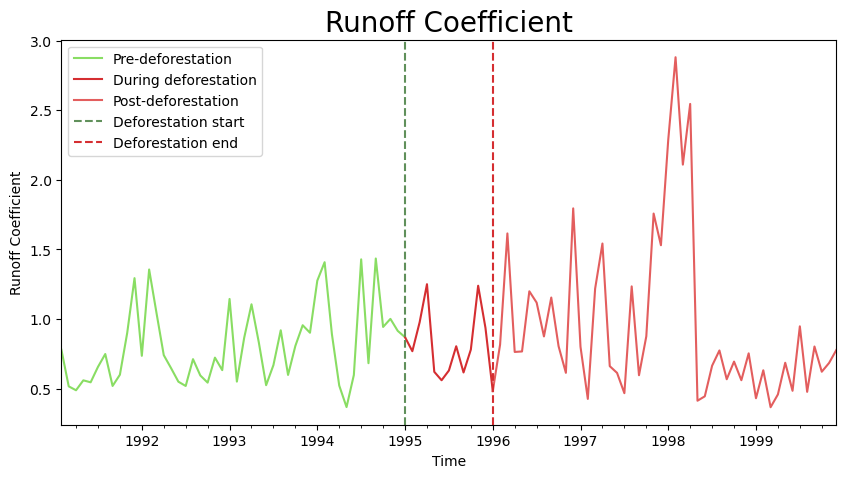

In [54]:
# Plot 
plt.figure(figsize=(10, 5))

Monthly['Runoff Coefficient'].loc['1991-01-16':'1995-01-01'].plot(color='#89DD63', label='Pre-deforestation')
Monthly['Runoff Coefficient'].loc['1995-01-01':'1996-01-01'].plot(color='#D52E31', label='During deforestation')
Monthly['Runoff Coefficient'].loc['1996-01-01':'1999-12-31'].plot(color='#E35E5E', label='Post-deforestation')
plt.axvline(x='1995-01-01', color='#60905B', linestyle='--', label='Deforestation start')
plt.axvline(x='1996-01-01', color='#D52E31', linestyle='--', label='Deforestation end')
plt.legend()
plt.title('Runoff Coefficient', fontdict=font, fontsize=20)
plt.xlabel('Time', fontdict=font)
plt.ylabel('Runoff Coefficient', fontdict=font);

To understand why the run-off coefficient is like this, the monthly rainfall and discharge are plotted below.

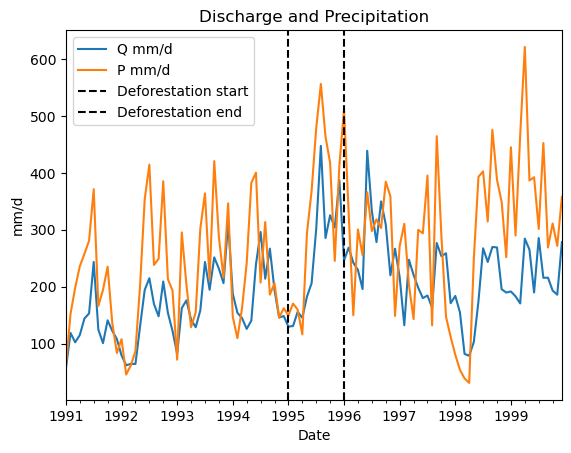

In [55]:
Monthly['Q mm/d'].plot()
Monthly['P mm/d'].plot()
plt.axvline(x='1995-01-01', color='black', linestyle='--', label='Deforestation start')
plt.axvline(x='1996-01-01', color='black', linestyle='--', label='Deforestation end')
plt.legend()
plt.title('Discharge and Precipitation')
plt.xlabel('Date')
plt.ylabel('mm/d');